# Monte Carlo and "the power of randomness"

:::{admonition} **What you will learn**

- **Monte Carlo = Random Sampling to Estimate Integrals**
  - Replace integration with **averaging over random samples**.

- **Expectation Viewpoint**:
  $$
  \int p(x) f(x)\,dx = \mathbb{E}_p\left[ f(x) \right]  \approx \frac{1}{n} \sum^{n}_{i=1} f(x_i)
  $$
  - Sample from  $ x_i \sim p(x) $, and compute averages of $f(x)$.

- **Law of Large Numbers**:
  - As $ n \to \infty $, sample average converges to the true expectation.

- **Boltzmann Sampling in Statistical Mechanics**:
  - Sample from $ p(x) \propto e^{-\beta E(x)} $ to estimate thermodynamic averages.

- **Curse of Dimensionality**:
  - Grid methods scale as $n^d$ — MC convergence rate $\mathcal{O}(n^{-1/2})$ is **dimension-independent**.

- **Rejection Sampling**:
  - Sample $ x \sim \text{Uniform} $, accept if $ y \leq f(x) $.
  - Useful for sampling from **unnormalized distributions**.

- **Importance Sampling**:
  - Reweight samples from an easy distribution to estimate expectations under a hard one.

:::

### Estimating the pi by throwing pebbles on the sand

- The key idea of this technique is that the ratio of the area of the circle to the square area that inscribes it is $\pi/4$, so by counting the fraction of the random points in the square that are inside the circle, we get increasingly good estimates to $\pi$.

$$\frac{V_{circle}}{V_{square}} = \frac{\pi r^2}{(2r)^2}  = \frac{\pi}{4}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def circle_pi_estimate(N=10000, r0=1):
    """
    Estimate the value of pi using the Monte Carlo method.
    
    Generate N random points in a square with sides ranging from -r0 to r0.
    Count the fraction of points that fall inside the inscribed circle to estimate pi.
    
    Parameters:
    N (int): Number of points to generate (default: 10000)
    r0 (int): Radius of the circle (default: 1)

    Returns:
    float: Estimated value of pi
    """

    # Generate random points
    xs = np.random.uniform(-r0, r0, size=N)
    ys = np.random.uniform(-r0, r0, size=N)

    # Calculate distances from the origin and determine points inside the circle
    inside = np.sqrt(xs**2 + ys**2) < r0
    
    # Compute volume ratio as the ratio of points
    v_ratio = inside.sum() / N

    pi_estimate = 4 * v_ratio
    
    # Plotting
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(xs[inside], ys[inside], 'b.', label='Inside')
    ax.plot(xs[~inside], ys[~inside], 'r.', label='Outside')
    ax.set_title(f"Estimation of $\\pi$ = {pi_estimate}", fontsize=20)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    
    return pi_estimate

3.14432

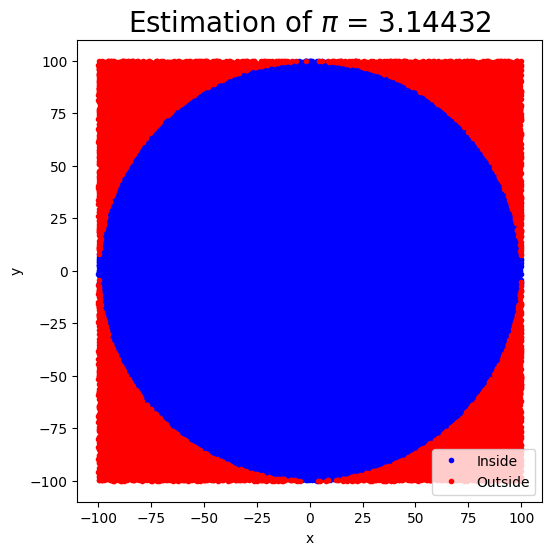

In [14]:
circle_pi_estimate(N=100000, r0=100)

### Shapes more complex than a circle

$$f(x) = e^{-x}+ e^{-x} x^2\cos^2(x) + e^{-2x}x^4 \cos^2(2x) $$


- We will now use the same technique but compute a 1D definite integral from $x_1$ to $x_2$ by drawing a rectangle to cover the curve with dimensions $x=[x_1,x_2]$ and $y= [0, L_y]$. 

- The area of the rectangle is $A = L_x \cdot L_y$. The area under the curve is $I$. 
- If we choose a point uniformly at random in the rectangle, what is the probability that the point falls into the region under the curve? It is simply

$$p = \frac{n_{\text{in}}}{N} \approx \frac{I}{A}$$ 

- Thus we can estimate the definite integral by drawing $N$ uniform points covering the rectangle and computing the integral as $I = A\cdot\frac{n_{\text{in}}}{N}$


Text(0, 0.5, 'f(x)')

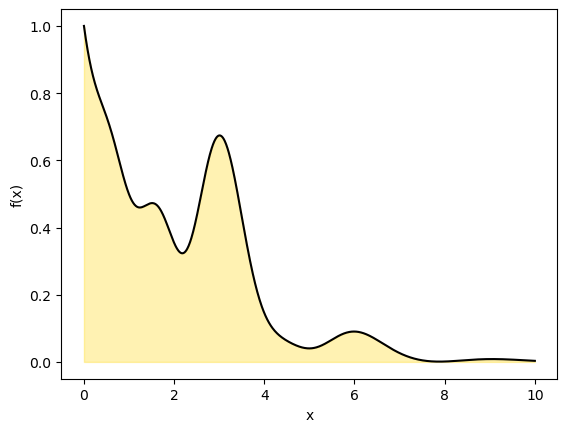

In [2]:
def myfunc1(x):
    return np.exp(-x)+ np.exp(-x)* x**2 * np.cos(x)**2 + np.exp(-2*x)*x**4* np.cos(2*x)**2

x= np.linspace(0, 10, 1000)
y = myfunc1(x)
plt.plot(x,y, c='k')
plt.fill_between(x, y,color='gold',alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')

Exact result: 2.289834301866351
MC result: 2.2561


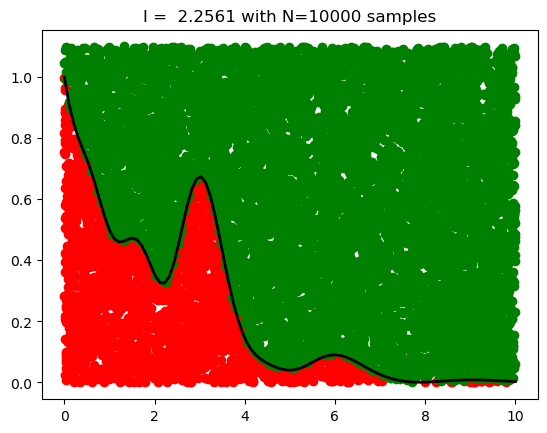

In [3]:
def mc_integral(func, 
                N=10000, 
                Lx=2, Ly=1, 
                plot=True):
    '''Generate random points in the square with [0, Lx] and [0, Ly]
      Count the fraction of points falling inside the curve
      '''
  
    # Generate uniform random numbers
    ux = Lx*np.random.rand(N) 
    uy = Ly*np.random.rand(N) 

    #Count accepted point.  
    pinside  = uy<func(ux)

    # Total area times fraction of sucessful points
    I = Lx*Ly*pinside.sum()/N 

    if plot==True:
    
      plt.plot(ux[pinside],  uy[pinside],'o', color='red')
      plt.plot(ux[~pinside], uy[~pinside],'o', color='green')

      x = np.linspace(0.001, Lx,100)
      plt.plot(x, func(x), color='black', lw=2)
      plt.title(f'I =  {I:.4f} with N={N} samples',fontsize=12)
      
    return I

### Calculate integral numerically first
from scipy import integrate

#adjust limits of x and y
Lx = 10  # x range from 0 to Lx
Ly = 1.1 # y range from 0 to Ly

y, err = integrate.quad(myfunc1, 0, Lx)

print("Exact result:", y)

I = mc_integral(myfunc1, N=10000, Lx=Lx, Ly=Ly) 

print("MC result:", I)


### The Essence of Monte Carlo Simulations

- Suppose we want to evaluate an integral $ I $.

$$I = \int f(x) \, dx$$

- A powerful perspective is to reinterpret this integral as the expectation of a function $ g(x) $ under some probability distribution $ p(x) $:

$$
I = \int \frac{f(x)}{p(x)} p(x) \, dx = \int g(x) \, p(x) \, dx = \mathbb{E}_p[g(x)]
$$

- In this form, the integral becomes the expected value of $ g(x) $ with respect to the distribution $ p(x) $. 
- To estimate $ \mathbb{E}_p[g] $, we draw samples $ x_i \sim p(x) $ and apply the **law of large numbers**, which guarantees that the sample average converges to the expected value as $ n \to \infty $:

$$
\mathbb{E}_p[g] \approx \frac{1}{n} \sum_{i=1}^n g(x_i), \quad \text{where } x_i \sim p(x)
$$


### Simple 1D applications of MC

#### Ordinary Monte Carlo and Uniform Sampling

- A common and intuitive case is when we draw samples uniformly from the interval $[a, b]$. In this setting, the sampling distribution is constant: $ p(x) = \frac{1}{b-a} $, and the integral simplifies as follows:

$$
I = \int_a^b f(x) \, dx = (b - a) \int_a^b \frac{f(x)}{b - a} \, dx \approx (b - a) \cdot \frac{1}{n} \sum_{i=1}^n f(x_i) = (b - a) \cdot \bar{f}_n
$$

- This gives a clear interpretation of Monte Carlo integration: we approximate the average height of the function $ f(x) $ over the interval by randomly sampling points, much like tossing pebbles onto a plot and estimating the shaded area.

In [4]:
x0, x1 = 0, 10
N = 100000
x = np.random.uniform(x0, x1, N)

integral = (x1 - x0) * np.mean(myfunc1(x))

print('MC result', integral)

y, err = integrate.quad(myfunc1, x0, x1)

print("Exact result:", y)

MC result 2.312692930908909
Exact result: 2.289834301866351


#### Sampling from the Boltzmann Distribution

- Quantities like average energy, heat capacity, or pressure are computed as **ensemble averages** under the Boltzmann distribution. 
- The Boltzmann distribution for a system with energy $E(x)$ at inverse temperature $\beta = 1/(k_B T)$ is:

$$
p(x) = \frac{e^{-\beta E(x)}}{Z}, \quad \text{where } Z = \int e^{-\beta E(x)} \, dx
$$

- Suppose we are interested in the average energy:

$$
\langle E \rangle = \int E(x) \, p(x) \, dx 
$$

- This is an **expectation value** under the Boltzmann distribution $p(x)$.  
- If we can draw samples $x_i \sim p(x)$, we can estimate $\langle E \rangle$ by:

$$
\langle E \rangle \approx \frac{1}{n} \sum_{i=1}^n E(x_i)
$$

Estimated ⟨E⟩: 0.4959
Exact ⟨E⟩:     0.5000


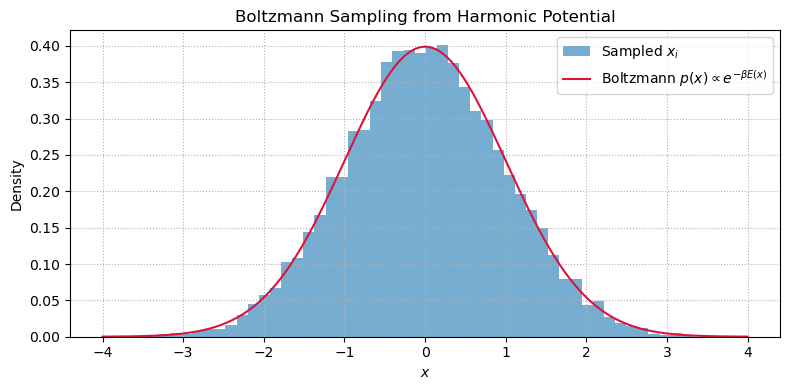

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
beta = 1.0  # inverse temperature
n_samples = 10000

# Boltzmann sampling for harmonic oscillator: Gaussian with variance 1/beta
x_samples = np.random.normal(loc=0.0, scale=np.sqrt(1 / beta), size=n_samples)

# Energy function E(x) = (1/2) * x^2
E = 0.5 * x_samples**2

# Estimate average energy ⟨E⟩
E_mean = np.mean(E)
E_exact = 0.5 / beta

print(f"Estimated ⟨E⟩: {E_mean:.4f}")
print(f"Exact ⟨E⟩:     {E_exact:.4f}")

# Plot histogram and overlay Boltzmann density
x_vals = np.linspace(-4, 4, 500)
p_vals = np.exp(-0.5 * beta * x_vals**2)
p_vals /= np.trapezoid(p_vals, x_vals)  # normalize for display

plt.figure(figsize=(8, 4))
plt.hist(x_samples, bins=50, density=True, alpha=0.6, label='Sampled $x_i$')
plt.plot(x_vals, p_vals, color='crimson', label='Boltzmann $p(x) \\propto e^{-\\beta E(x)}$')
plt.xlabel('$x$')
plt.ylabel('Density')
plt.title('Boltzmann Sampling from Harmonic Potential')
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

### MC Integration in Higher Dimensions

- Monte Carlo really shines in higher dimensions. Let's see it in action on a 2D function with sharp features — a mixture of Gaussians:

$$f(x,y) = \sum_{k} w_k \exp\!\left[-\frac{(x-\mu_k^x)^2 + (y-\mu_k^y)^2}{2\sigma_k^2}\right]$$

- This is a good proxy for physical problems where the integrand has localized peaks (e.g., partition functions, reaction coordinates).
- Notice how most uniform samples miss the peaks entirely — foreshadowing the need for smarter sampling.

### MC vs Grid: the Curse of Dimensionality

- The volume of a unit hypersphere in $d$ dimensions is $V_d = \frac{\pi^{d/2}}{\Gamma(d/2+1)}$.
- We can estimate it by MC: throw uniform points in the $[-1,1]^d$ hypercube, count the fraction inside $|\mathbf{r}| < 1$, and multiply by the cube volume $2^d$.
- As $d$ grows, the sphere shrinks relative to the cube — the "hit rate" drops exponentially.

**Two ways to do this MC integral — and they behave differently in high $d$:**

| Method | Formula | What happens as $d \to \infty$ |
|--------|---------|-------------------------------|
| **Hit-or-miss** | $V = 2^d \cdot \frac{n_{\text{in}}}{N}$ | Hit rate $\to 0$, so $\sigma^2$ grows $\Rightarrow$ **fails** |
| **Mean-value** | $V = 2^d \cdot \frac{1}{N}\sum f(\mathbf{x}_i)$ | Same formula, convergence rate is still $\mathcal{O}(N^{-1/2})$ |

- The convergence **rate** $\sigma/\sqrt{N}$ is always dimension-independent — that is the superpower of MC over grid methods (which need $n^d$ points).
- But $\sigma$ itself can grow with $d$ when you sample uniformly in a region where the integrand is mostly zero. This does not mean MC is broken — it means **uniform sampling is a bad choice of $q(x)$** in high dimensions.
- This is exactly what motivates **importance sampling** (choose a smarter $q$) and eventually **MCMC** (let the chain find the important regions automatically).

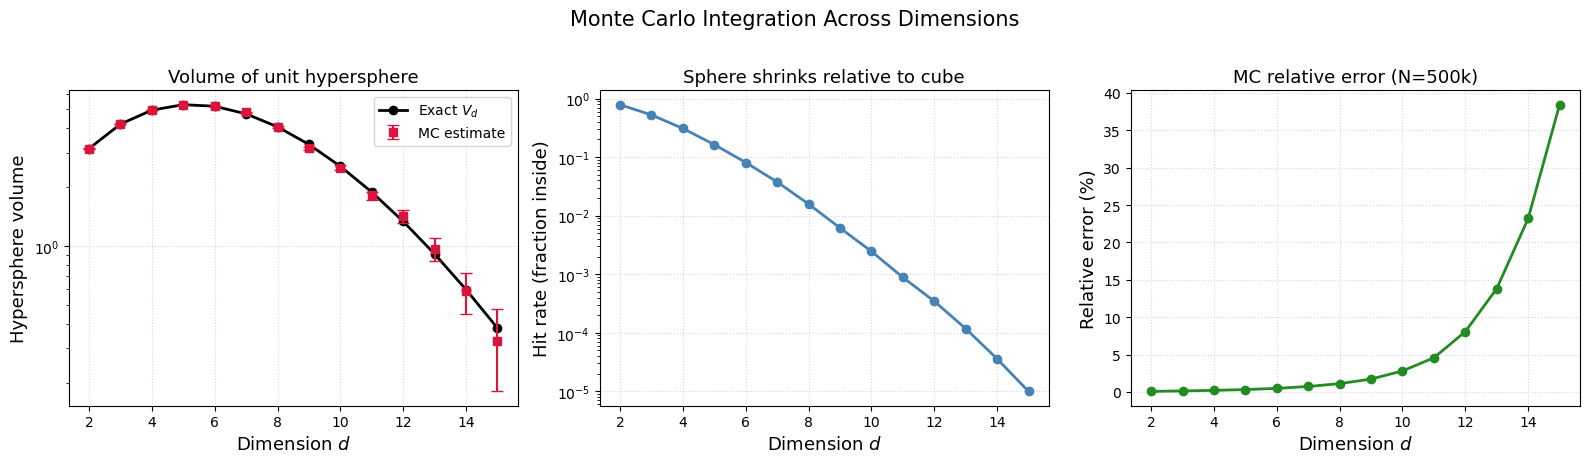

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

def hypersphere_volume_exact(d):
    """Exact volume of a unit hypersphere in d dimensions."""
    return np.pi**(d / 2) / gamma(d / 2 + 1)

def mc_hypersphere(d, N=500000):
    """MC estimate of the unit hypersphere volume in d dimensions."""
    points = np.random.uniform(-1, 1, size=(N, d))
    inside = np.sum(points**2, axis=1) < 1.0
    hit_rate = np.mean(inside)
    cube_vol = 2**d
    V_mc = cube_vol * hit_rate
    V_err = cube_vol * np.std(inside) / np.sqrt(N)
    return V_mc, V_err, hit_rate

dims = np.arange(2, 16)
V_exact = [hypersphere_volume_exact(d) for d in dims]
V_mc_vals, V_err_vals, hit_rates = zip(*[mc_hypersphere(d) for d in dims])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Left: exact vs MC volume
axes[0].semilogy(dims, V_exact, 'ko-', label='Exact $V_d$', lw=2)
axes[0].errorbar(dims, V_mc_vals, yerr=V_err_vals, fmt='s', color='crimson',
                 capsize=4, label='MC estimate')
axes[0].set_xlabel('Dimension $d$', fontsize=13)
axes[0].set_ylabel('Hypersphere volume', fontsize=13)
axes[0].set_title('Volume of unit hypersphere', fontsize=13)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

# Middle: hit rate (fraction inside sphere)
axes[1].semilogy(dims, hit_rates, 'o-', color='steelblue', lw=2)
axes[1].set_xlabel('Dimension $d$', fontsize=13)
axes[1].set_ylabel('Hit rate (fraction inside)', fontsize=13)
axes[1].set_title('Sphere shrinks relative to cube', fontsize=13)
axes[1].grid(True, linestyle=':', alpha=0.5)

# Right: relative error GROWS with d
rel_err = np.array(V_err_vals) / np.array(V_exact)
axes[2].plot(dims, rel_err * 100, 'o-', color='forestgreen', lw=2)
axes[2].set_xlabel('Dimension $d$', fontsize=13)
axes[2].set_ylabel('Relative error (%)', fontsize=13)
axes[2].set_title(r'Relative error grows: $\sigma$ grows with $d$', fontsize=13)
axes[2].grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Uniform MC integration across dimensions (N=500k)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nAt d=2:  hit rate = {hit_rates[0]:.3f},  relative error = {rel_err[0]*100:.1f}%")
print(f"At d=15: hit rate = {hit_rates[-1]:.5f},  relative error = {rel_err[-1]*100:.1f}%")
print(f"\nThe rate is always O(1/sqrt(N)), but sigma grows => need smarter sampling!")


### Why Does Monte Carlo Outperform Grids? And How to Reduce MC Error

- By the Central Limit Theorem, the MC estimator has standard error $\sigma_{\bar{g}} \propto n^{-1/2}$, **independent of dimension**.

- Deterministic grid methods converge as $\mathcal{O}(n^{-k/d})$ — they slow down exponentially as dimensionality grows (the **curse of dimensionality**).

- The MC error $\varepsilon = \sigma / \sqrt{n}$ has **two independent knobs**:

| Knob | What it does | How |
|------|-------------|-----|
| Increase $n$ | Shrink $1/\sqrt{n}$ | Throw more samples (brute force) |
| Decrease $\sigma$ | Shrink the prefactor | Sample where the integrand matters (**importance sampling**) |

- **When uniform sampling fails:** If $f(x)$ is sharply peaked (e.g., a Boltzmann factor $e^{-\beta E}$ at low $T$), most uniform samples land where $f \approx 0$. The variance $\sigma^2$ becomes enormous.

- **Importance sampling** attacks $\sigma$ directly: by sampling from a distribution $q(x)$ that concentrates points where $f(x)$ is large, the reweighted values $f(x_i)/q(x_i)$ become nearly constant, dramatically reducing variance.

- We will vary the sample size from 1 to 100 and calculate the value of $y = \sum{x}/n$ for 1000 replicates. We then plot the 2.5th and 97.5th percentile of the 1000 values of $y$ to see how the variation in $y$ changes with sample size.

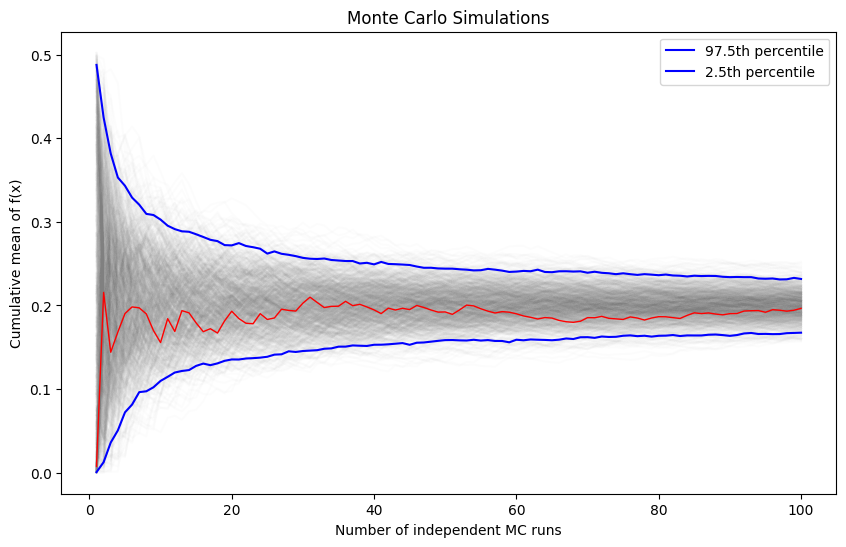

In [81]:
n = 100
reps = 1000

# Generating random numbers and applying the function
fx = f(np.random.random((n, reps)))

# Calculating cumulative mean for each simulation
y = np.cumsum(fx, axis=0) / np.arange(1, n+1)[:, None]

# Calculating the upper and lower percentiles
upper, lower = np.percentile(y, [97.5, 2.5], axis=1)

# Plotting the results
plt.figure(figsize=(10, 6))
for i in range(reps):
    plt.plot(np.arange(1, n+1), y[:, i], c='grey', alpha=0.02)
plt.plot(np.arange(1, n+1), y[:, 0], c='red', linewidth=1)
plt.plot(np.arange(1, n+1), upper, 'b', label='97.5th percentile')
plt.plot(np.arange(1, n+1), lower, 'b', label='2.5th percentile')

plt.xlabel('Number of independent MC runs')
plt.ylabel('Cumulative mean of f(x)')
plt.title('Monte Carlo Simulations')
plt.legend()
plt.show()

### Importance Sampling

- Suppose we want to evaluate the expectation of a function $ h(x) $ under a probability distribution $ p(x) $:

$$
I = \int h(x)\, p(x) \, dx
$$

- If sampling directly from $ p(x) $ is difficult, we can instead introduce an alternative distribution $ q(x) $ — one that is easier to sample from — and rewrite the integral as:

$$
I = \int h(x)\, p(x)\, dx = \int h(x)\, \frac{p(x)}{q(x)} \, q(x) \, dx
$$

- This reformulation allows us to draw samples $ y_i \sim q(x) $, and weight them by the **importance ratio** $ \frac{p(y_i)}{q(y_i)} $. The expectation can then be estimated using:

$$
I \approx \frac{1}{n} \sum_{i=1}^n \frac{p(y_i)}{q(y_i)} h(y_i)
$$

- This is the essence of **importance sampling**: reweighting samples from an easier distribution to approximate expectations under a more complex one.


### Rejection Sampling

- Rejection sampling turns uniformly distributed random numbers into samples from a target distribution.
- The key idea: draw a candidate $x$ uniformly and a height $y$ uniformly up to a bounding envelope. If $y \leq f(x)$, accept $x$; otherwise reject. The accepted samples follow the distribution $f(x)$.

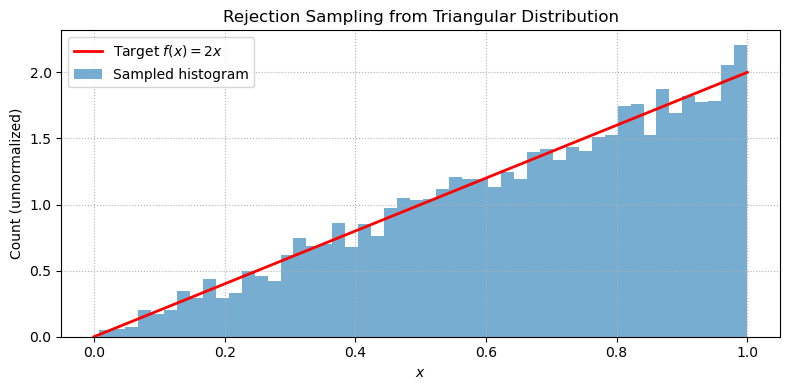

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Target unnormalized PDF: f(x) = 2x on [0, 1]
f = lambda x: 2 * x
Lx, Ly, N = 1, 2, 10000  # Domain, max height, number of samples

# Rejection sampling
x = Lx * np.random.rand(N)
y = Ly * np.random.rand(N)
accepted = x[y <= f(x)]

# Plot result
x_plot = np.linspace(0, 1, 500)
plt.figure(figsize=(8, 4))
plt.plot(x_plot, f(x_plot), 'r-', lw=2, label='Target $f(x) = 2x$')
plt.hist(accepted, bins=50, alpha=0.6, density=True, label='Sampled histogram')
plt.title('Rejection Sampling from Triangular Distribution')
plt.xlabel('$x$')
plt.ylabel('Count (unnormalized)')
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()


### Problems

#### Problem 1: MC with importance sampling

Evaluate the following integral using Monte Carlo methods:

$$\int^{\infty}_0 \frac{e^{-x}}{1+(x-1)^2} dx$$ 

- Start by doing a direct Monte Carlo estimate with uniform sampling on a finite interval $[0, L]$. 
- Try an importance sampling approach using an exponential distribution $q(x) = \lambda e^{-\lambda x}$. 
- Find the optimal value of $\lambda$ that gives the most rapid reduction of variance. [Hint: experiment with different values of $\lambda$ and plot the variance vs $\lambda$.]

#### Problem 2: MC integral of 3D and 6D spheres

- Generalize the MC code above for computing the volume of 3D and 6D spheres. 
- The analytical results are known: $V_{3d}=\frac{4}{3}\pi r^3$ and $V_{6d}=\frac{\pi^3}{6} r^6$. So you can check the statistical error made in the simulations. 

#### Problem 3: Convergence rate of MC

Consider the integral $I = \int_0^1 e^x \, dx = e - 1$.

- Estimate $I$ using uniform MC with sample sizes $N = 10, 100, 1000, 10000, 100000$.
- For each $N$, repeat the estimate 500 times and compute the standard deviation of the estimates.
- Plot the standard deviation vs $N$ on a log-log scale. Verify that the error decreases as $\mathcal{O}(N^{-1/2})$.
- How does the prefactor (the variance of $e^x$ on $[0,1]$) compare to your observed intercept?

#### Problem 4: Rejection sampling from the Boltzmann distribution

Use rejection sampling to draw samples from the Boltzmann distribution of a double-well potential:

$$E(x) = (x^2 - 1)^2$$

- Use a uniform proposal distribution over $[-2, 2]$ with an appropriate bounding constant $M$.
- Sample at two temperatures: $k_BT = 1.0$ (low) and $k_BT = 5.0$ (high).
- Plot histograms of accepted samples and overlay the exact Boltzmann distribution $p(x) \propto e^{-\beta E(x)}$.
- Report the acceptance rate for each temperature. Why does it change?